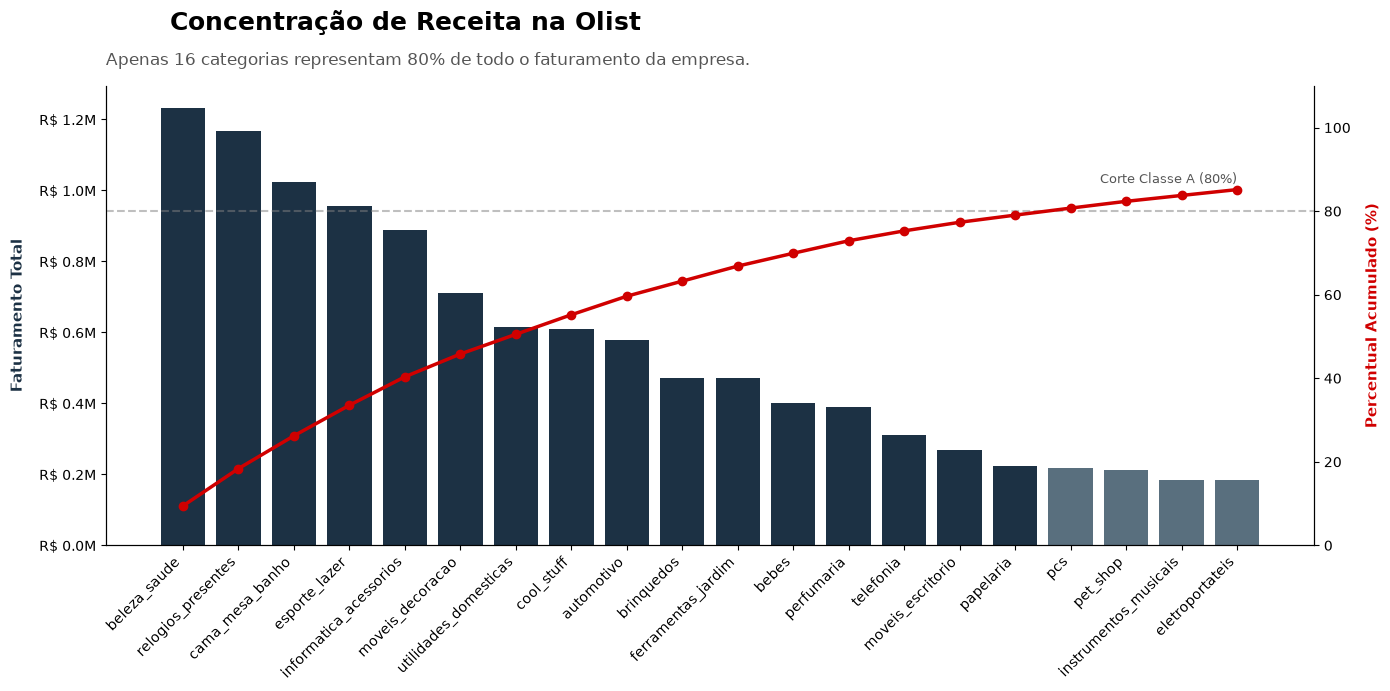

In [32]:
# ==========================================
# IMPORTS E CONFIGURAÇÕES
# ==========================================
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pd.set_option('display.max_columns', None)

# ==========================================
# 1. EXTRAÇÃO E TRANSFORMAÇÃO (ETL)
# ==========================================
# Carga dos dados brutos
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')

# Filtros e Joins encadeados
orders_delivered = orders[orders['order_status'] == 'delivered']

df_merged = (
    order_items
    .merge(orders_delivered[['order_id']], on='order_id')
    .merge(products[['product_id', 'product_category_name']], on='product_id')
    .dropna(subset=['product_category_name'])
)

# Agregação de faturamento e volume
resumo_categoria = df_merged.groupby('product_category_name').agg(
    quantidade_vendida=('order_item_id', 'count'),
    faturamento_total=('price', 'sum')
).reset_index()

# ==========================================
# 2. CARGA E ANÁLISE SQL (CURVA ABC)
# ==========================================
query_curva_abc = """
WITH faturamento_acumulado AS (
    SELECT product_category_name,
           faturamento_total,
           SUM(faturamento_total) OVER (ORDER BY faturamento_total DESC) AS acumulado,
           SUM(faturamento_total) OVER () AS total_geral
    FROM faturamento_categoria
),
percentual AS (
    SELECT product_category_name,
           faturamento_total,
           acumulado,
           ROUND(acumulado * 100.0 / total_geral, 2) AS percentual_acumulado
    FROM faturamento_acumulado
)
SELECT product_category_name,
       faturamento_total,
       percentual_acumulado,
       CASE
           WHEN percentual_acumulado <= 80 THEN 'A'
           WHEN percentual_acumulado <= 95 THEN 'B'
           ELSE 'C'
       END AS classe_abc
FROM percentual
ORDER BY faturamento_total DESC;
"""

# Execução no banco de dados usando Context Manager
with sqlite3.connect('../banco_olist.db') as conn:
    resumo_categoria.to_sql('faturamento_categoria', conn, if_exists='replace', index=False)
    curva_abc = pd.read_sql_query(query_curva_abc, conn)

# ==========================================
# 3. VISUALIZAÇÃO DE DADOS (PARETO)
# ==========================================
df_grafico = curva_abc.head(20).copy()

cores = df_grafico['classe_abc'].map({
    'A': '#1C3144',
    'B': '#596F7E',
    'C': '#D3DCE6'
})

fig, ax1 = plt.subplots(figsize=(14, 7))

# Eixo Y Principal (Barras de Faturamento)
ax1.bar(df_grafico['product_category_name'], df_grafico['faturamento_total'], color=cores, edgecolor='none')
ax1.set_ylabel('Faturamento Total', color='#1C3144', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_xticks(range(len(df_grafico['product_category_name'])))
ax1.set_xticklabels(df_grafico['product_category_name'], rotation=45, ha='right', fontsize=10)

# Formatação em Milhões via Lambda
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:.1f}M'))

# Eixo Y Secundário (Percentual Acumulado)
ax2 = ax1.twinx()
ax2.plot(df_grafico['product_category_name'], df_grafico['percentual_acumulado'], 
         color='#D00000', marker='o', linewidth=2.5, markersize=6)
ax2.set_ylabel('Percentual Acumulado (%)', color='#D00000', fontsize=11, fontweight='bold', labelpad=10)
ax2.set_ylim(0, 110)

# Linhas de referência e Data-Ink Ratio
ax2.axhline(80, color='gray', linestyle='--', alpha=0.5, zorder=0)
ax2.text(len(df_grafico)-1, 86, 'Corte Classe A (80%)', color='#555555', ha='right', va='bottom', fontsize=9)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Títulos dinâmicos
qtd_classe_a = (curva_abc['classe_abc'] == 'A').sum()
plt.suptitle('Concentração de Receita na Olist', fontsize=18, fontweight='bold', x=0.125, y=0.98, ha='left')
plt.title(f'Apenas {qtd_classe_a} categorias representam 80% de todo o faturamento da empresa.', 
          fontsize=12, color='#555555', loc='left', pad=15)

plt.tight_layout()
plt.savefig('grafico_curva_abc.png', dpi=300, bbox_inches='tight')
plt.show()